# Practice Project Overview
This assignment is split into two parts. Part 1 will give you the opportunity to demonstrate your plotting and visualization skills and Part 2 is about creating and customizing dashboards.
- Part 1 : Analyzing the wildfire activities in Australia
- Part 2 : Dashboard to display charts based on selected Region and Year

## Data Description
This wildfire dataset contains data on fire activities in Australia starting from 2005. Additional information can be found [here](https://earthdata.nasa.gov/earth-observation-data/near-real-time/firms/c6-mcd14dl?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMSkillsNetworkDV0101ENCoursera2761-2023-01-01).

The dataset includes the following variables:
- Region: the 7 regions
- Date: in UTC and provide the data for 24 hours ahead
- Estimated_fire_area: daily sum of estimated fire area for presumed vegetation fires with a confidence > 75% for a each region in km2
- Mean_estimated_fire_brightness: daily mean (by flagged fire pixels(=count)) of estimated fire brightness for presumed vegetation fires with a confidence level > 75% in Kelvin
- Mean_estimated_fire_radiative_power: daily mean of estimated radiative power for presumed vegetation fires with a confidence level > 75% for a given region in megawatts
- Mean_confidence: daily mean of confidence for presumed vegetation fires with a confidence level > 75%
- Std_confidence: standard deviation of estimated fire radiative power in megawatts
- Var_confidence: Variance of estimated fire radiative power in megawatts
- Count: daily numbers of pixels for presumed vegetation fires with a confidence level of larger than 75% for a given region
- Replaced: Indicates with an Y whether the data has been replaced with standard quality data when they are available (usually with a 2-3 month lag). Replaced data has a slightly higher quality in terms of locations

## Part 1 : Analyzing the wildfire activities in Australia

### Objectives
The objective of this part of the Practice Assignment is to analyze and visualize the wildfire activities in Australia using the provided dataset. You will explore patterns and trends, and create visualizations to gain insights into the behavior of wildfires in different regions of Australia.

In this lab you will create visualizations using Matplotlib, Seaborn, Pandas and Folium.

### Tasks to be performed
**TASK 1.1**: To understand the change in average estimated fire area over time using pandas to plot the line chart.

**TASK 1.2**: To plot the estimated fire area over month

**TASK 1.3**: Use the functionality of seaborn to develop a barplot, to find the insights on the distribution of mean estimated fire brightness across the regions

**TASK 1.4**: Develop a pie chart and find the portion of count of pixels for presumed vegetation fires vary across regions

**TASK 1.5**: Customize the previous pie plot for a better visual representation

**TASK 1.6**: Use Matplotlib to develop a histogram of the mean estimated fire brightness

**TASK 1.7**: Use the functionality of seaborn and pass region as hue, to understand the distribution of estimated fire brightness across regions

**TASK 1.8**: Develop a scatter plot to find the correlation between mean estimated fire radiative power and mean confidence level

**TASK 1.9**: Mark all seven regions affected by wildfires, on the Map of Australia using Folium

## Part 2 : Dashboard to display charts based on selected Region and Year

### Objectives
The objective of this part of the practice assignment is to create dashboards to contain your plots and charts.

In this lab you will create dashboards using Dash and Plotly and then add user-interactions to your dashboards.

You will be required to create a dashboard wherein the user can select the Region and the Year. Based on the selection, the dashboard will display the following two charts:
- Pie Chart on Monthly Average Estimated Fire Area
- Bar Chart on Monthly Average Count of Pixels for Presumed Vegetation Fires

### Tasks to be performed
**TASK 2.1**: Add title to the dashboard

**TASK 2.2**: Add the radio items and a dropdown right below the first inner division

**TASK 2.3**: Add two empty divisions for output inside the next inner division

**TASK 2.4**: Add the Ouput and input components inside the app.callback decorator

**TASK 2.5**: Add the callback function

Good Luck!

---

## Part 1 - Analyzing wildfire activities

In [49]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import folium
import calendar
import requests
from IPython.display import JSON
%matplotlib inline

In [2]:
# Import dataset
url = '/'.join(["https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud",
                "IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv"])
df = pd.read_csv(url)

In [3]:
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26406 entries, 0 to 26405
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Region                               26406 non-null  object 
 1   Date                                 26406 non-null  object 
 2   Estimated_fire_area                  26406 non-null  float64
 3   Mean_estimated_fire_brightness       26406 non-null  float64
 4   Mean_estimated_fire_radiative_power  26406 non-null  float64
 5   Mean_confidence                      26406 non-null  float64
 6   Std_confidence                       24199 non-null  float64
 7   Var_confidence                       24199 non-null  float64
 8   Count                                26406 non-null  int64  
 9   Replaced                             26406 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 2.0+ MB


**TASK 1.1**: Change in average estimated fire area over time

In [5]:
df['Date']=pd.to_datetime(df['Date'])

In [6]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26406 entries, 0 to 26405
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Region                               26406 non-null  object        
 1   Date                                 26406 non-null  datetime64[ns]
 2   Estimated_fire_area                  26406 non-null  float64       
 3   Mean_estimated_fire_brightness       26406 non-null  float64       
 4   Mean_estimated_fire_radiative_power  26406 non-null  float64       
 5   Mean_confidence                      26406 non-null  float64       
 6   Std_confidence                       24199 non-null  float64       
 7   Var_confidence                       24199 non-null  float64       
 8   Count                                26406 non-null  int64         
 9   Replaced                             26406 non-null  object        
 10  Year      

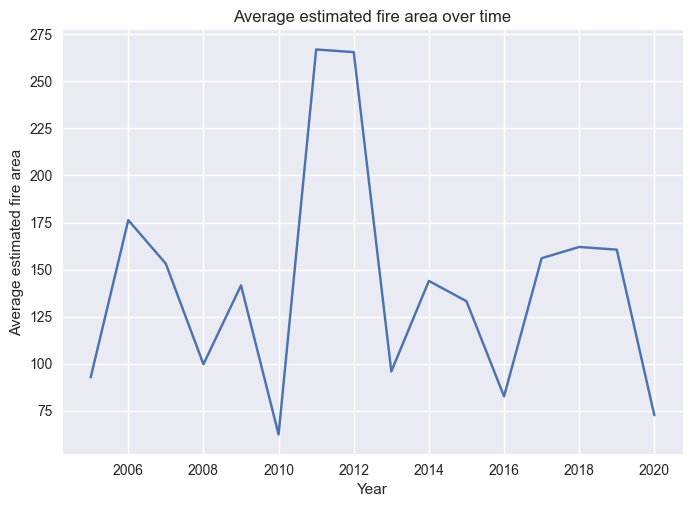

In [44]:
df.groupby('Year')['Estimated_fire_area'].mean().plot()

plt.title('Average estimated fire area over time')
plt.xlabel('Year')
plt.ylabel('Average estimated fire area')
plt.style.use('seaborn-v0_8')
plt.show()

**TASK 1.2**: To plot the estimated fire area over month

In [9]:
df1 = df.groupby(['Year','Month'])['Estimated_fire_area'].mean()
df1.head()

Year  Month
2005  1         70.619908
      2        101.018747
      3         40.901576
      4         69.305388
      5         93.834520
Name: Estimated_fire_area, dtype: float64

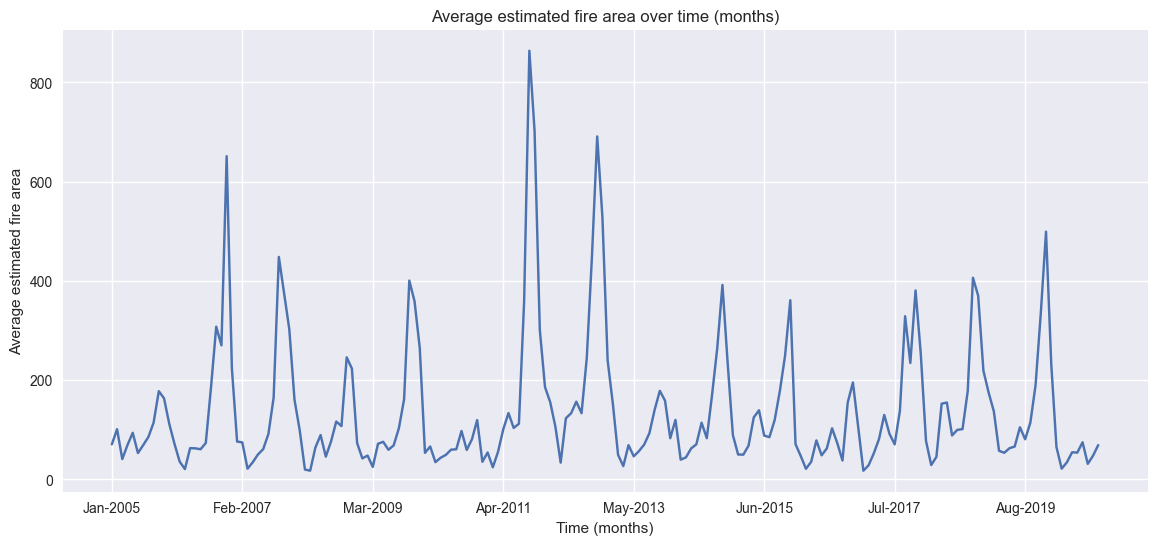

In [10]:
import calendar
ax = df1.plot(figsize=(14,6))
ax.set_title('Average estimated fire area over time (months)')
ax.set_xlabel('Time (months)')

xticks_index = [
    i for i in ax.get_xticks().astype(int)
    if 0 <= i < len(df1)
]

xtick_labels = [
    f'{calendar.month_abbr[month]}-{year}'
    for year,month in df1.index[xticks_index]
]

ax.set_xticks(xticks_index)
ax.set_xticklabels(xtick_labels)
ax.set_ylabel('Average estimated fire area')
plt.style.use('seaborn-v0_8')
plt.show()

**TASK 1.3**: Use the functionality of seaborn to develop a barplot, to find the insights on the distribution of mean estimated fire brightness across the regions

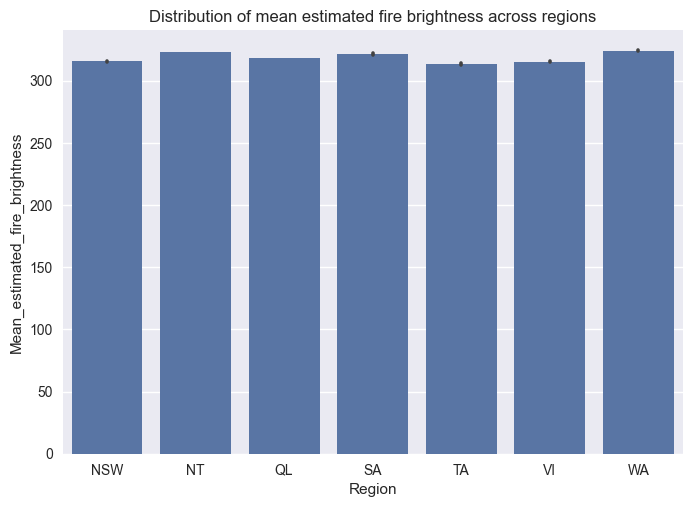

In [11]:
sns.barplot(df, x='Region', y='Mean_estimated_fire_brightness')
plt.title('Distribution of mean estimated fire brightness across regions')
plt.style.use('seaborn-v0_8')
plt.show()

**TASK 1.4 & 1.5**: Develop a pie chart and find the portion of count of pixels for presumed vegetation fires vary across regions

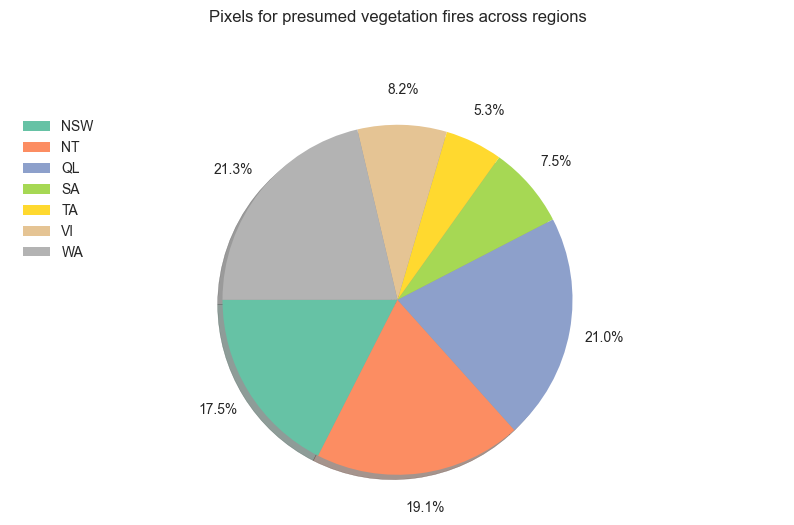

In [12]:
df.groupby('Region')['Count'].count().plot(
    kind='pie',
    figsize=(10,5),
    startangle=180,
    shadow=True,
    labels=None,
    autopct='%1.1f%%',
    pctdistance=1.2,
    colormap='Set2',
)

plt.title('Pixels for presumed vegetation fires across regions', y=1.2)
plt.ylabel(None)
plt.axis('equal')
plt.legend(labels=df['Region'].unique(),loc='upper left', fontsize=10)
plt.style.use('seaborn-v0_8')
plt.show()

**TASK 1.6**: Use Matplotlib to develop a histogram of the mean estimated fire brightness

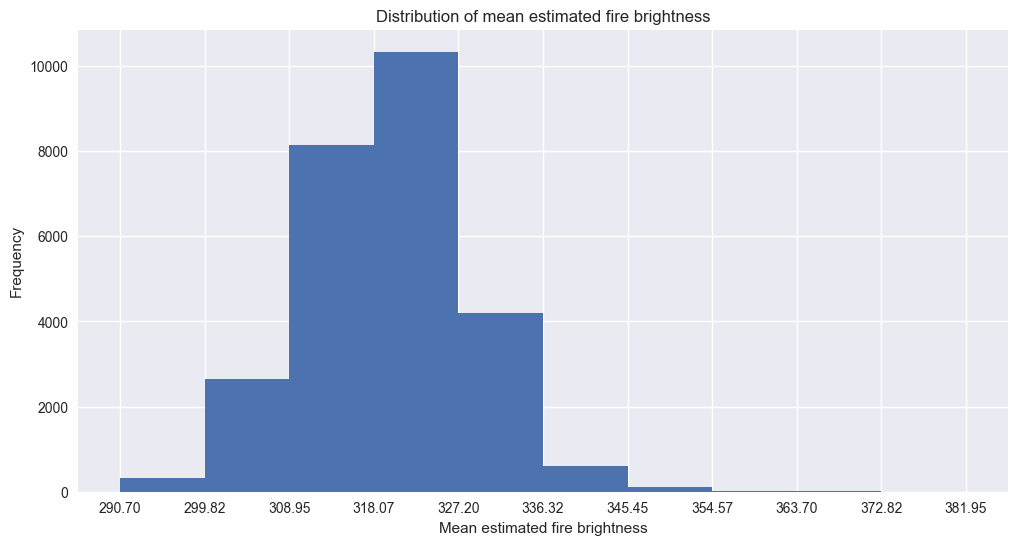

In [13]:
counts, bins = np.histogram(df['Mean_estimated_fire_brightness'])

df['Mean_estimated_fire_brightness'].plot(
    kind='hist',
    figsize=(12,6)
)

plt.xticks(bins)
plt.title('Distribution of mean estimated fire brightness')
plt.xlabel('Mean estimated fire brightness')
plt.style.use('seaborn-v0_8')
plt.show()

**TASK 1.7**: Use the functionality of seaborn and pass region as hue, to understand the distribution of estimated fire brightness across regions

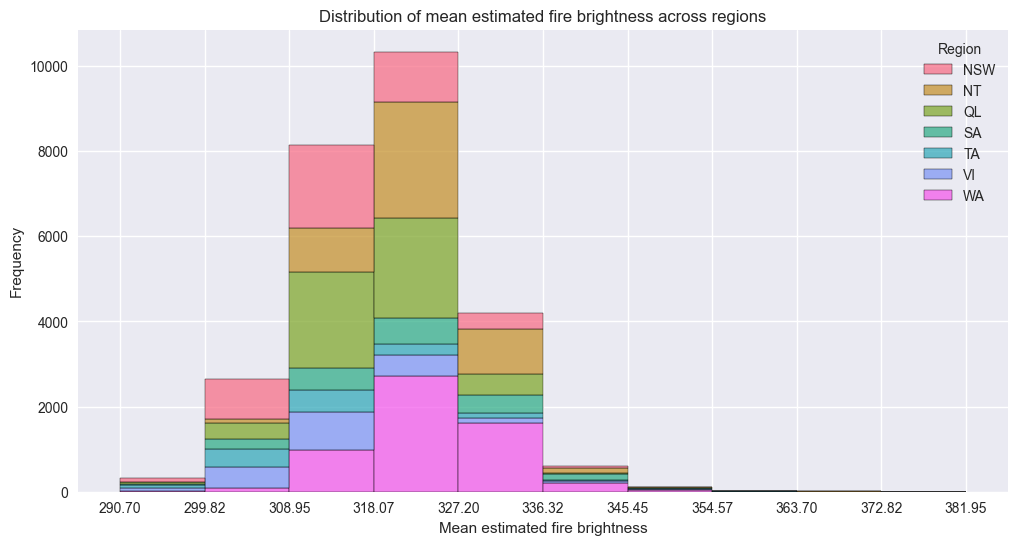

In [24]:
plt.figure(figsize=(12,6))
sns.histplot(
    data = df,
    x = 'Mean_estimated_fire_brightness',
    hue = 'Region',
    bins = bins,
    multiple = 'stack'
)
plt.title('Distribution of mean estimated fire brightness across regions')
plt.xlabel('Mean estimated fire brightness')
plt.xticks(bins)
plt.ylabel('Frequency')
plt.show()

**TASK 1.8**: Develop a scatter plot to find the correlation between mean estimated fire radiative power and mean confidence level

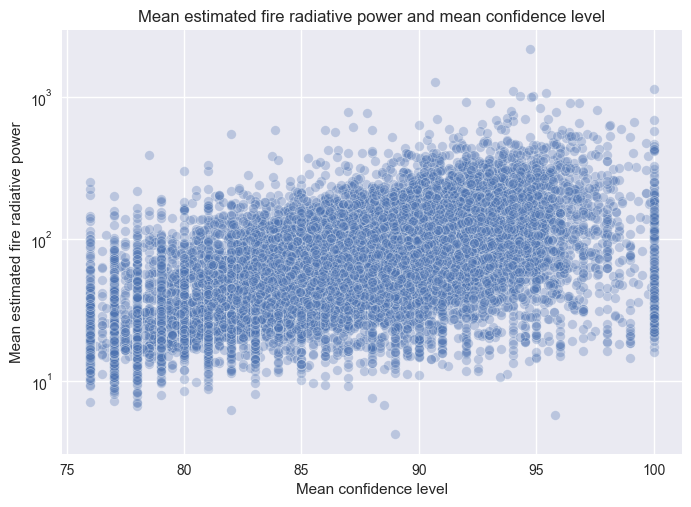

In [43]:
plt.figure()
sns.scatterplot(
    x=df['Mean_confidence'],
    y=df['Mean_estimated_fire_radiative_power'],
    legend=None,
    alpha=0.3
)
plt.title('Mean estimated fire radiative power and mean confidence level')
plt.xlabel('Mean confidence level')
plt.ylabel('Mean estimated fire radiative power')
plt.yscale('log')
plt.show()

**TASK 1.9**: Mark all seven regions affected by wildfires, on the Map of Australia using Folium

In [64]:
regdict = dict(
    zip(
        df['Region'].unique().tolist(),
        ["New South Wales","Northern Territory","Queensland","South Australia",
         "Tasmania","Victoria","Western Australia","Australian Capital Territory"]
    )
)

In [68]:
df['Region_FN'] = df['Region'].apply(lambda x: regdict[x])
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced,Year,Month,Region_FN
0,NSW,2005-01-04,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R,2005,1,New South Wales
1,NSW,2005-01-05,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R,2005,1,New South Wales
2,NSW,2005-01-06,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R,2005,1,New South Wales
3,NSW,2005-01-07,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R,2005,1,New South Wales
4,NSW,2005-01-08,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R,2005,1,New South Wales


In [114]:
df_mefb = df.groupby('Region_FN', as_index=False)['Mean_estimated_fire_brightness'].mean()
df_mefb

,Region_FN,Mean_estimated_fire_brightness
0,New South Wales,315.526218
1,Northern Territory,322.898453
2,Queensland,318.364434
3,South Australia,321.497609
4,Tasmania,313.368483
5,Victoria,315.029792
6,Western Australia,324.142246


In [116]:
australia_geo = requests.get(
    'https://raw.githubusercontent.com/anthwri/GeoJson-Data/refs/heads/master/australian-states.json'
).json()

In [117]:
JSON(australia_geo)

<IPython.core.display.JSON object>

In [160]:
australia_map = folium.Map([-25.2744, 133.7751], zoom_start=4)

chpth = folium.Choropleth(
    geo_data = australia_geo,
    data = df_mefb,
    columns = ['Region_FN','Mean_estimated_fire_brightness'],
    key_on = 'feature.properties.STATE_NAME',
    fill_color = 'YlOrRd',
    fill_opacity = 0.6,
    line_opacity = 0.2,
    legend_name='Mean Estimated Fire Brightness (pixels)',
    highlight=True,
).add_to(australia_map)

for region in chpth.geojson.data['features']:
    region_name = region['properties']['STATE_NAME']
    
    if region_name != 'Australian Capital Territory':
        region['properties']['Fire_Brightness'] = np.round(
            df_mefb.set_index('Region_FN').loc[region_name,'Mean_estimated_fire_brightness'], 2
        )
    else:
        region['properties']['Fire_Brightness'] = np.nan

folium.GeoJsonTooltip(
    ['STATE_NAME', 'Fire_Brightness'],
    aliases = ['Region', 'Fire Brightness']
).add_to(chpth.geojson)

folium.LayerControl().add_to(australia_map)

australia_map

## Author
Christian Jelo Artoza